# Error Analysis & Robustness Check — GeoATM LightGBM

**Задача:** регрессия — числовая оценка успешности места под банкомат.
**Финальная модель:** LightGBM (Optuna-100, сохранена в `models/lightgbm_best.txt`).
**Данные:** `data/train_data_v2.csv` — 6 200 строк, 67 признаков.

### Цели ноутбука
1. Понять, **где и почему** модель ошибается.
2. Классифицировать ошибки: исправимые / неисправимые.
3. Проверить **устойчивость** предсказаний к малым изменениям входных признаков.

> MLflow UI → http://localhost:5050 · MinIO UI → http://localhost:9001

# 1. Настройки, данные, метрики

In [173]:
import os, sys, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import mlflow

from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score, median_absolute_error
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.5f}".format)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = Path("../reports/error_analysis_robustness")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output →", OUTPUT_DIR.resolve())

Output → /Users/marianikitcenko/GeoATM-popularity/reports/error_analysis_robustness


### 1.1. MLflow / MinIO

In [143]:
MLFLOW_URI = "http://localhost:5050"
mlflow.set_tracking_uri(MLFLOW_URI)
os.environ["AWS_ACCESS_KEY_ID"]      = "admin"
os.environ["AWS_SECRET_ACCESS_KEY"]  = "password"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "http://localhost:9000"

EXPERIMENT_NAME = "GeoATM-ErrorAnalysis-v2"
mlflow.set_experiment(EXPERIMENT_NAME)
print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow tracking URI: http://localhost:5050


---

### 1.2. Загрузка данных

Датасет: 6200 строк × 134 колонок
Таргет 'target': min=-0.1450  max=0.2186  mean=0.0008  std=0.0859


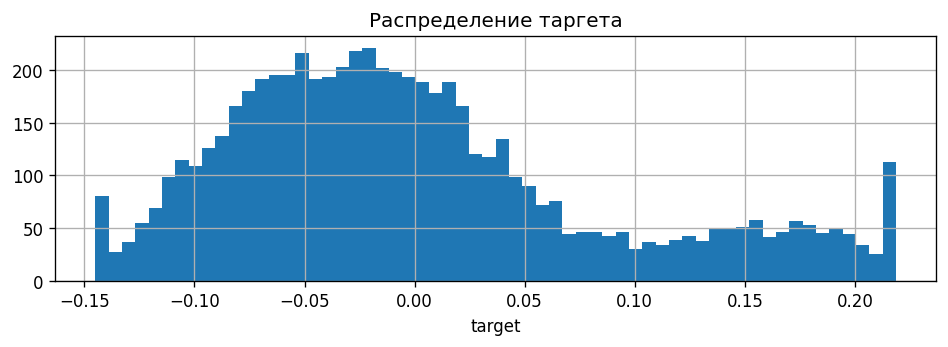

In [144]:
DATA_PATH = Path("../data/train_data_v2.csv")
df_raw = pd.read_csv(DATA_PATH)
print(f"Датасет: {df_raw.shape[0]} строк × {df_raw.shape[1]} колонок")

TARGET_COL = "target"
print(f"Таргет '{TARGET_COL}': min={df_raw[TARGET_COL].min():.4f}  "
      f"max={df_raw[TARGET_COL].max():.4f}  mean={df_raw[TARGET_COL].mean():.4f}  "
      f"std={df_raw[TARGET_COL].std():.4f}")
df_raw[TARGET_COL].hist(bins=60, figsize=(8, 3))
plt.title("Распределение таргета"); plt.xlabel(TARGET_COL); plt.tight_layout(); plt.show()

### 1.3. Признаки и препроцессинг

In [145]:
BINARY_FEATURES = [
    "is_24_7","contactless_tech","qr_codes","usd_available","eur_available",
    "cash_in","cash_out","cashless_pay","account_statement","access_for_disabled",
    "transfer_p2p","transfer_a2a","loan_payments",
    "is_federal_city","is_federal_district_capital","is_city_center","has_subway_nearby",
]
DISTANCE_FEATURES = [
    "nearest_malls_dist_m","nearest_supermarkets_dist_m",
    "nearest_pharmacies_hospitals_dist_m","nearest_cafes_dist_m",
    "nearest_restaurants_dist_m","nearest_public_transport_dist_m",
    "nearest_parking_dist_m","nearest_education_dist_m","nearest_subway_dist_m",
    "nearest_post_offices_dist_m","nearest_offices_dist_m",
    "nearest_shops_food_small_dist_m","nearest_fitness_sport_dist_m",
    "nearest_hotels_hostels_dist_m","land_use_dist_m","city_center_dist_m",
    "nearest_residential_landuse_dist_m",
]
COUNT_FEATURES = [
    "count_malls_300m","count_supermarkets_300m","count_pharmacies_hospitals_300m",
    "count_banks_atms_300m","count_cafes_300m","count_restaurants_300m",
    "count_public_transport_300m","count_parking_300m","count_education_300m",
    "count_post_offices_300m","count_offices_300m","count_payment_terminals_300m",
    "count_money_transfer_300m","count_shops_food_small_300m","count_hypermarkets_300m",
    "count_markets_300m","count_fitness_sport_300m","count_hotels_hostels_300m",
    "count_railway_stations_300m","count_residential_buildings_300m",
    "count_residential_landuse_300m","count_fuel_300m",
    "count_highway_pedestrian_300m","count_landuse_mix_300m","count_footway_100m_100m",
]
ECONOMIC_FEATURES = [
    "avg_salary_oct_2025_rub","grp_per_capita_2023_rub",
    "avg_income_q3_2025_rub","population_density_per_km2",
]
CATEGORICAL_FEATURES = ["federal_district","city_size_category","land_use_type","atm_group"]

ALL_FEATURES = (BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES +
                ECONOMIC_FEATURES + CATEGORICAL_FEATURES)
ALL_FEATURES = [f for f in ALL_FEATURES if f in df_raw.columns]
NUM_FEATURES  = [f for f in BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES + ECONOMIC_FEATURES
                 if f in df_raw.columns]
CAT_FEATURES  = [f for f in CATEGORICAL_FEATURES if f in df_raw.columns]

print(f"Итого признаков: {len(ALL_FEATURES)}  (num={len(NUM_FEATURES)}, cat={len(CAT_FEATURES)})")

Итого признаков: 67  (num=63, cat=4)


In [146]:
def preprocess(df, imputer=None, fit_imputer=True):
    X = df[ALL_FEATURES].copy()
    # bool -> int
    for c in BINARY_FEATURES:
        if c in X.columns and X[c].dtype == bool:
            X[c] = X[c].astype(int)
    # distance -> log1p
    for c in DISTANCE_FEATURES:
        if c in X.columns:
            X[c] = np.log1p(X[c].clip(lower=0))
    # numeric imputation
    num_in = [c for c in NUM_FEATURES if c in X.columns]
    if fit_imputer:
        imputer = SimpleImputer(strategy="median")
        X[num_in] = imputer.fit_transform(X[num_in])
    else:
        X[num_in] = imputer.transform(X[num_in])
    # categorical
    for c in CAT_FEATURES:
        X[c] = X[c].fillna("unknown").astype("category")
    return X, imputer

df = df_raw.dropna(subset=[TARGET_COL]).reset_index(drop=True)
y  = df[TARGET_COL].values
X_full, imp_full = preprocess(df)
print("X_full:", X_full.shape, "| NaN:", X_full.isnull().any().any())

X_full: (6200, 67) | NaN: False


### 1.4. Загрузка финальной модели

Финальная модель сохранена как нативный LightGBM booster (`models/lightgbm_best.txt`).

In [147]:
MODEL_PATH = Path("../models/lightgbm_best.txt")


best_model = lgb.Booster(model_file=str(MODEL_PATH))
print("Загружена лучшая модель:", MODEL_PATH,
          "| n_features =", best_model.num_feature())

Загружена лучшая модель: ../models/lightgbm_best.txt | n_features = 67


### 1.5. Предсказания финальной модели

In [148]:
y_pred_full = best_model.predict(X_full)
print(f"pred: min={y_pred_full.min():.4f}  max={y_pred_full.max():.4f}  "
      f"mean={y_pred_full.mean():.4f}")
print("Это предсказания на обучающих данных. Для честной оценки см. OOF ниже (раздел 8).")

pred: min=-0.1334  max=0.2140  mean=0.0008
Это предсказания на обучающих данных. Для честной оценки см. OOF ниже (раздел 8).


### 1.6. Честные OOF-предсказания (KFold=5)

Финальная модель обучена на 85% данных, поэтому предсказания на обучающих данных — оптимистичны.
Для честного анализа ошибок используем **out-of-fold** предсказания с теми же гиперпараметрами.

In [149]:
BEST_PARAMS = dict(
    n_estimators=2000,
    learning_rate=0.05044609107189108,
    num_leaves=41, max_depth=9, min_child_samples=50,
    subsample=0.9153045607247461, colsample_bytree=0.9148769651655132,
    reg_alpha=0.028948720938703567, reg_lambda=0.47568902097824295,
    random_state=RANDOM_STATE, verbosity=-1,
)
N_SPLITS = 5

def make_oof(X, y, params=BEST_PARAMS, n_splits=N_SPLITS):
    oof = np.zeros(len(X))
    kf  = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    for fold, (tr, va) in enumerate(kf.split(X), 1):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        _, imp = preprocess(df.iloc[tr])          # fit imputer on fold-train only
        X_tr2, _ = preprocess(df.iloc[tr], imp, fit_imputer=False)
        X_va2, _ = preprocess(df.iloc[va], imp, fit_imputer=False)
        m = lgb.LGBMRegressor(**params)
        m.fit(X_tr2, y[tr],
              eval_set=[(X_va2, y[va])],
              callbacks=[lgb.early_stopping(100, verbose=False)])
        oof[va] = m.predict(X_va2)
        print(f"  fold {fold}: MAE={mean_absolute_error(y[va], oof[va]):.5f}")
        print(f"  fold {fold}: RMSE={mean_squared_error(y[va], oof[va])**0.5:.5f}")
        print(f"  fold {fold}: R²={r2_score(y[va], oof[va]):.5f}")
    return oof

y_pred = make_oof(X_full, y)
print(f"\nOOF MAE  = {mean_absolute_error(y, y_pred):.5f}")
print(f"OOF RMSE = {mean_squared_error(y, y_pred)**0.5:.5f}")
print(f"OOF R²   = {r2_score(y, y_pred):.5f}")

  fold 1: MAE=0.03547
  fold 1: RMSE=0.04469
  fold 1: R²=0.73092
  fold 2: MAE=0.03571
  fold 2: RMSE=0.04530
  fold 2: R²=0.73784
  fold 3: MAE=0.03453
  fold 3: RMSE=0.04435
  fold 3: R²=0.73083
  fold 4: MAE=0.03471
  fold 4: RMSE=0.04433
  fold 4: R²=0.72436
  fold 5: MAE=0.03512
  fold 5: RMSE=0.04422
  fold 5: R²=0.72939

OOF MAE  = 0.03511
OOF RMSE = 0.04458
OOF R²   = 0.73084


### 1.7. Метрики качества

In [150]:
def regression_metrics(y_true, y_pred, label=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    medae= median_absolute_error(y_true, y_pred)
    abs_y = np.abs(y_true)
    if (abs_y > 1e-6).all():
        mape = float(np.mean(np.abs((y_true - y_pred) / abs_y)) * 100)
    else:
        mape = None
    abserr = np.abs(y_true - y_pred)
    pct = {p: np.percentile(abserr, p) for p in [50, 75, 90, 95, 99]}
    rows = [
        ("MAE",   f"{mae:.5f}"),
        ("RMSE",  f"{rmse:.5f}"),
        ("R²",    f"{r2:.5f}"),
        ("Median AE", f"{medae:.5f}"),
    ] + [(f"p{p} AE", f"{v:.5f}") for p, v in pct.items()]
    t = pd.DataFrame(rows, columns=["Метрика", "Значение"])
    if label: print(f"{'='*30} {label} {'='*30}")
    display(t)
    return dict(mae=mae, rmse=rmse, r2=r2, medae=medae, mape=mape, pct=pct)

metrics = regression_metrics(y, y_pred, "OOF")

============================== OOF ==============================


,Метрика,Значение
0,MAE,0.03511
1,RMSE,0.04458
2,R²,0.73084
3,Median AE,0.02945
4,p50 AE,0.02945
5,p75 AE,0.04970
6,p90 AE,0.07261
7,p95 AE,0.08668
8,p99 AE,0.12184


# 2. Анализ ошибок

### 2.1. Распределение ошибок

In [151]:
def build_error_dataframe(df, y_true, y_pred):
    a = df.copy()
    a["y_true"] = y_true
    a["y_pred"] = y_pred
    a["error"]  = y_pred - y_true
    a["abs_error"] = np.abs(a["error"])
    a["relative_error"] = a["abs_error"] / np.maximum(np.abs(y_true), 1e-9)
    return a

analysis_df = build_error_dataframe(df, y, y_pred)
analysis_df.to_csv(OUTPUT_DIR / "predictions_with_errors.csv", index=False)
analysis_df[["y_true","y_pred","error","abs_error","relative_error"]].describe()

,y_true,y_pred,error,abs_error,relative_error
count,6200.00000,6200.00000,6200.00000,6200.00000,6200.00000
mean,0.00083,0.00128,0.00045,0.03511,2.62885
std,0.08593,0.07321,0.04458,0.02747,25.06243
min,-0.14500,-0.11960,-0.19209,0.00000,0.00003
25%,-0.06117,-0.04613,-0.02945,0.01369,0.24247
50%,-0.01545,-0.02430,-0.00145,0.02945,0.54825
75%,0.04020,0.01367,0.02946,0.04970,1.19302
max,0.21861,0.20255,0.18219,0.19209,1396.11791


### 2.2. Общая диагностика ошибок

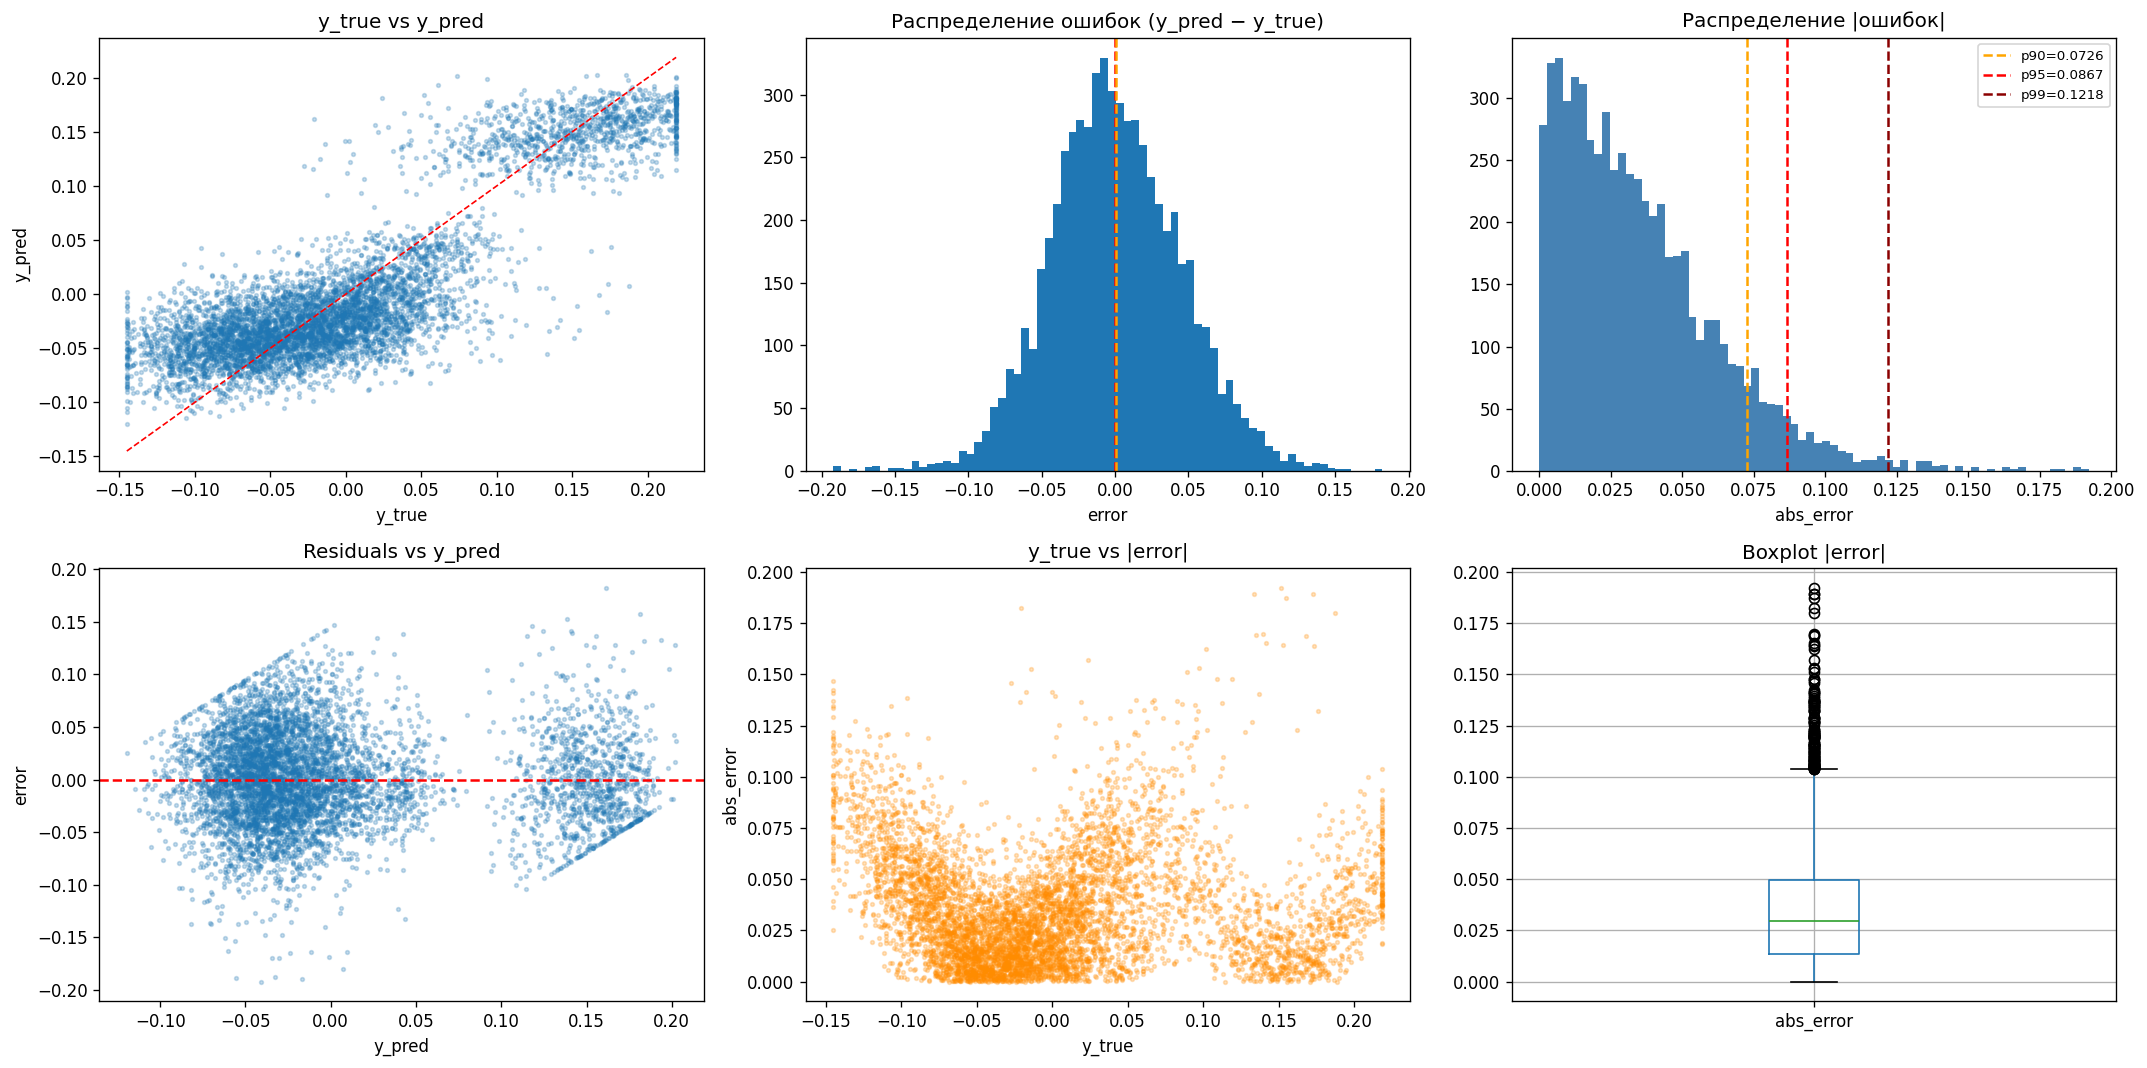

In [152]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# 1. pred vs true
ax = axes[0, 0]
ax.scatter(analysis_df["y_true"], analysis_df["y_pred"], s=5, alpha=.25)
lim = [analysis_df["y_true"].min(), analysis_df["y_true"].max()]
ax.plot(lim, lim, "r--", lw=1)
ax.set(title="y_true vs y_pred", xlabel="y_true", ylabel="y_pred")

# 2. residuals distribution
ax = axes[0, 1]
ax.hist(analysis_df["error"], bins=70, edgecolor="none")
ax.axvline(0, color="r", ls="--"); ax.axvline(analysis_df["error"].mean(), color="orange", ls="--")
ax.set(title="Распределение ошибок (y_pred − y_true)", xlabel="error")

# 3. abs error distribution
ax = axes[0, 2]
ax.hist(analysis_df["abs_error"], bins=70, edgecolor="none", color="steelblue")
for p, v in {90: "orange", 95: "red", 99: "darkred"}.items():
    ax.axvline(np.percentile(analysis_df["abs_error"], p), color=v, ls="--",
               label=f"p{p}={np.percentile(analysis_df['abs_error'],p):.4f}")
ax.legend(fontsize=8); ax.set(title="Распределение |ошибок|", xlabel="abs_error")

# 4. residuals vs pred
ax = axes[1, 0]
ax.scatter(analysis_df["y_pred"], analysis_df["error"], s=5, alpha=.25)
ax.axhline(0, color="r", ls="--")
ax.set(title="Residuals vs y_pred", xlabel="y_pred", ylabel="error")

# 5. y_true vs abs_error
ax = axes[1, 1]
ax.scatter(analysis_df["y_true"], analysis_df["abs_error"], s=5, alpha=.25, color="darkorange")
ax.set(title="y_true vs |error|", xlabel="y_true", ylabel="abs_error")

# 6. boxplot + percentile
ax = axes[1, 2]
analysis_df.boxplot(column="abs_error", ax=ax)
ax.set(title="Boxplot |error|")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "residuals_overview.png", dpi=120, bbox_inches="tight")
plt.show()

**Интерпретация (слева направо, сверху вниз):**

- **y_true vs y_pred** — в идеале точки лежат на красной диагонали. Веер расширяется на хвостах: модель тянет экстремальные значения к центру → **регрессия к среднему**. Это статистический эффект: модель систематически «боится» экстремальных предсказаний и тянет их к среднему значению таргета (≈ 0.0008 в нашем случае).
- **Распределение ошибок** — распределение близко к нормальному, систематического смещения нет.
- **Распределение модуля ошибок** — показывает, насколько часто встречаются большие ошибки. Вертикальные линии — перцентили p90/p95/p99: например, p95 = 0.0867 означает, что у 5% объектов ошибка выше этого значения. Большая часть ошибок в диапазоне [0, 0.025], распределение сильно скошено.
- **Residuals vs y_pred** — если остатки случайны и центрированы около нуля на всём диапазоне предсказаний, модель адекватна. Мы наблюдаем «бабочку» (расширение на краях) - это говорит о гетероскедастичности: дисперсия ошибки растёт для экстремальных предсказаний. В нашем случае это прямое следствие регрессии к среднему: модель предсказывает экстремальные значения реже и менее уверенно. 
- **y_true vs |error|** — где концентрируются крупные ошибки в зависимости от истинного значения. Скопление ошибок в районе отрицательных y_true подтверждает, что нижний дециль предсказывается хуже всего.
- **Boxplot |error|** — сводная статистика абсолютных ошибок: медиана, IQR, усы и выбросы. Точки выше верхнего уса — кандидаты на детальный разбор в разделе 12.

__Промежуточные выводы:__

Таргет в данных близок к нормальному распределению — скошенности практически нет (mean ≈ 0.0008, std = 0.086), поэтому проблема в том, что у экстремальных объектов недостаточно уникальных признаков, которые бы однозначно отличали их от средних.

Модель не видит сигнала, чтобы уверенно предсказать −0.14 или +0.20. 

### 2.3. Поиск аномально больших ошибок

Объект помечается как «плохое предсказание», если попал хотя бы в один из шести методов.

| Метод | Условие | Поймано |
|---|---|---|
| **Top-20 по abs_error** | 20 объектов с наибольшим `\|y_pred − y_true\|` | 20 |
| **Top-20 по relative_error** | 20 объектов с наибольшим `abs_error / \|y_true\|` | 20 |
| **p95** | `abs_error > 95-й перцентиль` | 310 |
| **p99** | `abs_error > 99-й перцентиль` | 62 |
| **IQR** | `abs_error > Q3 + 1.5 × IQR` (правило Тьюки) | 141 |
| **Z-score** | `\|z\| > 3`,  z = (abs_error − mean) / std | 79 |
| **Robust z-score** | `rz > 3`,  rz = (abs_error − median) / (1.4826 × MAD) | 118 |

Итого помечено: **328 объектов (5.3%)**.

In [153]:
def find_large_errors(adf, n_top=20):
    ae = adf["abs_error"]
    q3, q1 = ae.quantile(0.75), ae.quantile(0.25)
    iqr = q3 - q1
    z = (ae - ae.mean()) / ae.std()
    mad = np.median(np.abs(ae - ae.median()))
    rz  = (ae - ae.median()) / (1.4826 * mad + 1e-12)

    flags = pd.DataFrame(index=adf.index)
    flags["top_abs"] = ae.rank(ascending=False) <= n_top
    flags["top_rel"] = adf["relative_error"].rank(ascending=False) <= n_top
    flags["p95"] = ae > ae.quantile(0.95)
    flags["p99"] = ae > ae.quantile(0.99)
    flags["iqr"] = ae > q3 + 1.5 * iqr
    flags["zscore"] = z.abs() > 3
    flags["robust_z"] = rz > 3
    flags["any_flag"] = flags.any(axis=1)

    bad = adf[flags["any_flag"]].copy()
    bad["error_flag"] = flags[flags["any_flag"]].apply(
        lambda r: ", ".join([c for c in flags.columns[:-1] if r[c]]), axis=1)
    return bad.sort_values("abs_error", ascending=False), flags

bad_cases_df, flags = find_large_errors(analysis_df)
print(f"Помечено как плохие предсказания: {len(bad_cases_df)} из {len(analysis_df)}")
bad_cases_df[["y_true","y_pred","error","abs_error","relative_error","error_flag"]
             + CAT_FEATURES[:4]].head(20)

Помечено как плохие предсказания: 328 из 6200


,y_true,y_pred,error,abs_error,relative_error,error_flag,federal_district,city_size_category,land_use_type,atm_group
31,0.15123,-0.04087,-0.19209,0.19209,1.27023,"top_abs, p95, p99, iqr, zscore, robust_z",СЗФО,medium,commercial,32.00000
2028,0.17272,-0.01662,-0.18934,0.18934,1.09623,"top_abs, p95, p99, iqr, zscore, robust_z",ЦФО,million+,commercial,32.00000
22,0.13335,-0.05565,-0.18900,0.18900,1.41736,"top_abs, p95, p99, iqr, zscore, robust_z",ПФО,large,residential,32.00000
26,0.15453,-0.03275,-0.18728,0.18728,1.21192,"top_abs, p95, p99, iqr, zscore, robust_z",СФО,NaN,commercial,32.00000
2792,-0.02089,0.16129,0.18219,0.18219,8.71968,"top_abs, p95, p99, iqr, zscore, robust_z",ЦФО,large,commercial,8083.00000
24,0.18715,0.00702,-0.18012,0.18012,0.96247,"top_abs, p95, p99, iqr, zscore, robust_z",СФО,NaN,residential,32.00000
28,0.13954,-0.03023,-0.16977,0.16977,1.21661,"top_abs, p95, p99, iqr, zscore, robust_z",ЮФО,medium,industrial,32.00000
1785,0.13473,-0.03452,-0.16926,0.16926,1.25623,"top_abs, p95, p99, iqr, zscore, robust_z",ЦФО,million+,commercial,3185.50000
2027,0.16787,-0.00076,-0.16863,0.16863,1.00453,"top_abs, p95, p99, iqr, zscore, robust_z",ЦФО,million+,commercial,32.00000
2029,0.14147,-0.02378,-0.16525,0.16525,1.16806,"top_abs, p95, p99, iqr, zscore, robust_z",ЦФО,NaN,residential,32.00000


In [154]:
# Сводка по методам обнаружения
print("Метод          | Кол-во объектов")
print("-" * 35)
for col in ["top_abs","top_rel","p95","p99","iqr","zscore","robust_z"]:
    print(f"{col:<15}| {flags[col].sum()}")

Метод          | Кол-во объектов
-----------------------------------
top_abs        | 20
top_rel        | 20
p95            | 310
p99            | 62
iqr            | 141
zscore         | 79
robust_z       | 118


### 2.4. Сегментный анализ ошибок

Глобальный MAE (0.035) маскирует неравномерность: модель может работать хорошо в среднем, но систематически ошибаться на отдельных группах объектов. Сегментный анализ выявляет такие группы.

### Два типа анализа

**По категориальным признакам** (`federal_district`, `city_size_category`, `land_use_type`, `atm_group`)
Для каждой группы считаются: количество объектов, MAE, медианная ошибка, RMSE, средний таргет и bias (`mean(y_pred − y_true)`). Учитываются только группы с ≥ 30 объектами.

**По числовым признакам** — бинирование через `pd.qcut`
Каждый числовой признак разбивается на 10 децилей, для каждого бина считается MAE. Затем ищутся бины, где MAE значимо выше среднего (ratio > 1).

### Ключевые находки

| Сегмент | MAE | Отклонение от среднего |
|---|---|---|
| `atm_group = 32` | 0.091 | **+160%** — критически высокая ошибка |
| `federal_district = ДФО` | 0.038 | +8%, но bias ≈ 0 - незначимр |
| `city_size = medium` | 0.036 | +3% — незначимо |
| `land_use = industrial` | 0.036 | +2% — незначимо |

По числовым признакам наибольший ratio у **`nearest_public_transport_dist_m`** (бин 260–993 м) и **`count_public_transport_300m`** (0–1 объекта рядом) — объекты с плохой транспортной доступностью предсказываются хуже.

In [155]:
def segment_error_analysis(adf, cat_cols, num_cols, min_count=30):
    results_cat = {}
    for c in cat_cols:
        if c not in adf.columns: continue
        g = adf.groupby(c).agg(
            count=("abs_error","size"),
            mean_abs_error=("abs_error","mean"),
            median_abs_error=("abs_error","median"),
            rmse=("error", lambda x: (x**2).mean()**.5),
            mean_y_true=("y_true","mean"),
            mean_y_pred=("y_pred","mean"),
            bias=("error","mean"),
        )
        results_cat[c] = g[g["count"] >= min_count].sort_values("mean_abs_error", ascending=False)
    return results_cat

cat_summary = segment_error_analysis(analysis_df, CAT_FEATURES, NUM_FEATURES)

for feat, tbl in cat_summary.items():
    print(f"\n{'='*60}\n{feat}")
    display(tbl.round(5))


federal_district


,count,mean_abs_error,median_abs_error,rmse,mean_y_true,mean_y_pred,bias
federal_district,,,,,,,
ДФО,788,0.03802,0.03204,0.04813,0.03263,0.03170,-0.00092
СКФО,63,0.03706,0.03304,0.04593,-0.02262,-0.01955,0.00307
СФО,1303,0.03672,0.03059,0.04637,0.00285,0.00298,0.00013
ЮФО,377,0.03565,0.02770,0.04648,0.00320,0.00351,0.00031
УФО,349,0.03483,0.02866,0.04370,-0.01731,-0.01569,0.00162
ЦФО,1714,0.03444,0.02875,0.04406,0.00803,0.00836,0.00032
ПФО,1130,0.03321,0.02966,0.04126,-0.02648,-0.02593,0.00054
СЗФО,476,0.03231,0.02642,0.04173,-0.00393,-0.00121,0.00272



city_size_category


,count,mean_abs_error,median_abs_error,rmse,mean_y_true,mean_y_pred,bias
city_size_category,,,,,,,
medium,1010,0.03643,0.03128,0.04563,-0.00450,-0.00394,0.00056
large,1091,0.03390,0.02842,0.04352,-0.00720,-0.00610,0.00110
million+,2102,0.03267,0.02709,0.04188,0.01396,0.01412,0.00016



land_use_type


,count,mean_abs_error,median_abs_error,rmse,mean_y_true,mean_y_pred,bias
land_use_type,,,,,,,
industrial,457,0.03567,0.03009,0.04515,-0.00321,-0.00264,0.00058
commercial,2933,0.03515,0.02933,0.04470,0.00981,0.00993,0.00012
residential,2516,0.03500,0.02964,0.04444,-0.01034,-0.00959,0.00075
unknown,294,0.03470,0.02848,0.04372,0.01303,0.01405,0.00103



atm_group


,count,mean_abs_error,median_abs_error,rmse,mean_y_true,mean_y_pred,bias
atm_group,,,,,,,
32.00000,43,0.09124,0.09047,0.10961,0.00820,-0.01499,-0.02319
3185.50000,587,0.03965,0.03356,0.04934,-0.04366,-0.04112,0.00254
496.50000,615,0.03933,0.03430,0.04960,-0.04759,-0.04633,0.00126
8083.00000,1040,0.03499,0.02973,0.04432,0.15132,0.15025,-0.00107
1942.00000,1148,0.03366,0.02754,0.04277,0.00422,0.00484,0.00063
5478.00000,2631,0.03329,0.02861,0.04166,-0.03436,-0.03381,0.00055
1022.00000,136,0.02699,0.02369,0.03349,-0.08923,-0.08582,0.00341


In [156]:
# Числовые признаки — ошибка по бинам
def numeric_binned_error(adf, num_cols, n_bins=10):
    rows = []
    overall_mae = adf["abs_error"].mean()
    overall_rmse = (adf["error"]**2).mean()**.5
    for c in num_cols:
        if c not in adf.columns or adf[c].nunique() < 5: continue
        try:
            adf2 = adf.copy()
            adf2["_bin"] = pd.qcut(adf[c], q=n_bins, duplicates="drop")
            g = adf2.groupby("_bin").agg(
                count=("abs_error","size"),
                mean_abs_error=("abs_error","mean"),
                rmse=("error", lambda x: (x**2).mean()**.5),
                bias=("error","mean"),
            ).reset_index()
            worst_bin = g.loc[g["mean_abs_error"].idxmax(), "_bin"]
            rows.append(dict(
                feature=c,
                worst_bin=str(worst_bin),
                worst_mae=g["mean_abs_error"].max(),
                worst_rmse=g["rmse"].max(),
                overall_mae=overall_mae,
                overall_rmse=overall_rmse,
                ratio=g["mean_abs_error"].max() / overall_mae,
            ))
        except Exception:
            pass
    return pd.DataFrame(rows).sort_values("ratio", ascending=False)

num_summary = numeric_binned_error(analysis_df, NUM_FEATURES)
print("Числовые признаки с наибольшим ratio worst_bin_MAE / overall_MAE:")
display(num_summary.head(15).round(4))
num_summary.to_csv(OUTPUT_DIR / "numeric_binned_error.csv", index=False)

Числовые признаки с наибольшим ratio worst_bin_MAE / overall_MAE:


,feature,worst_bin,worst_mae,worst_rmse,overall_mae,overall_rmse,ratio
5,nearest_public_transport_dist_m,"(259.9, 993.1]",0.04050,0.05020,0.03510,0.04460,1.15260
23,count_public_transport_300m,"(-0.001, 1.0]",0.03990,0.04980,0.03510,0.04460,1.13720
41,grp_per_capita_2023_rub,"(2463550.0, 10462220.0]",0.03980,0.04990,0.03510,0.04460,1.13380
15,city_center_dist_m,"(14297.44, 64644.5]",0.03950,0.04930,0.03510,0.04460,1.12450
1,nearest_supermarkets_dist_m,"(347.8, 994.3]",0.03930,0.04870,0.03510,0.04460,1.11800
43,population_density_per_km2,"(1.84, 4.29]",0.03910,0.04920,0.03510,0.04460,1.11440
42,avg_income_q3_2025_rub,"(130000.0, 150000.0]",0.03850,0.04890,0.03510,0.04460,1.09660
20,count_banks_atms_300m,"(-0.001, 1.0]",0.03820,0.04750,0.03510,0.04460,1.08670
37,count_highway_pedestrian_300m,"(1.0, 33.0]",0.03810,0.04830,0.03510,0.04460,1.08650
2,nearest_pharmacies_hospitals_dist_m,"(368.42, 1079.6]",0.03800,0.04800,0.03510,0.04460,1.08370


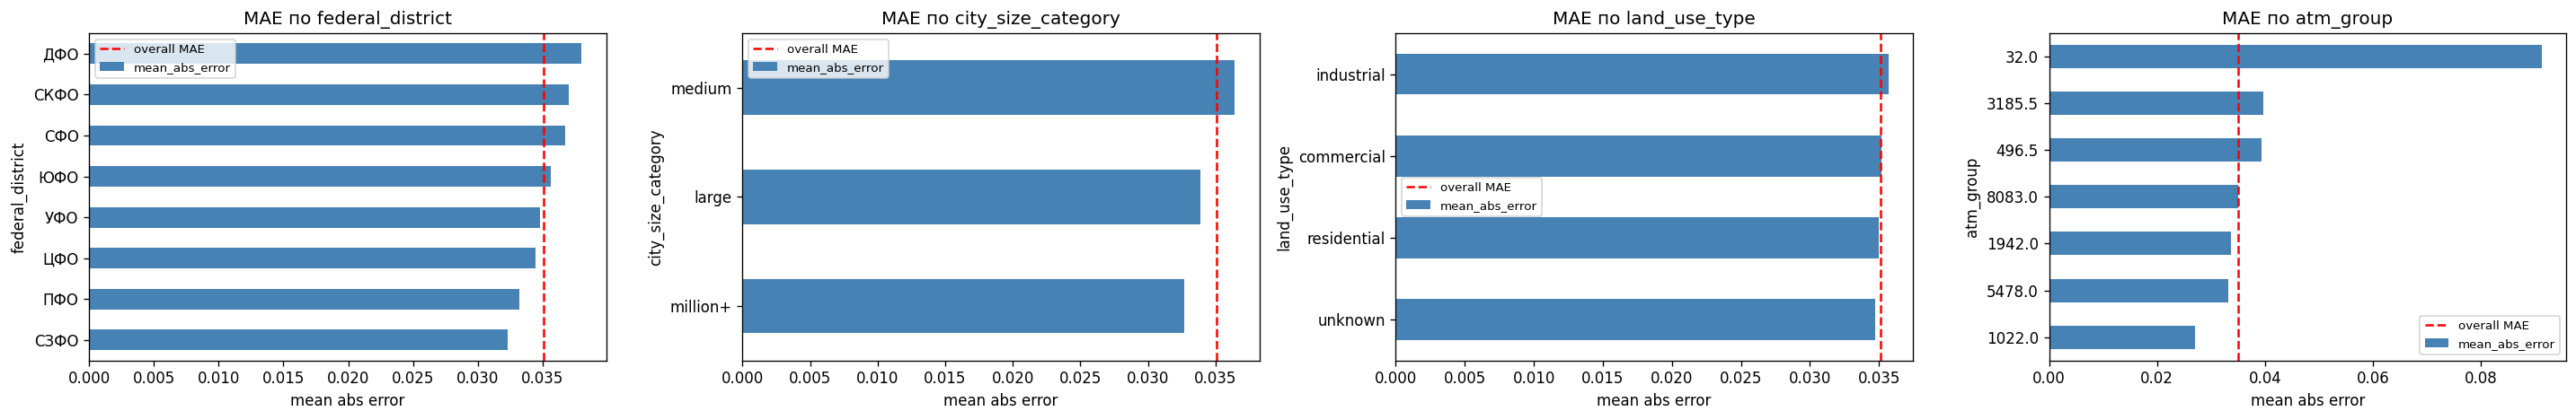

In [157]:
fig, axes = plt.subplots(1, len(cat_summary), figsize=(6*len(cat_summary), 4), squeeze=False)
for ax, (feat, tbl) in zip(axes[0], cat_summary.items()):
    tbl["mean_abs_error"].plot(kind="barh", ax=ax, color="steelblue")
    ax.axvline(analysis_df["abs_error"].mean(), color="r", ls="--", label="overall MAE")
    ax.invert_yaxis(); ax.legend(fontsize=8)
    ax.set(title=f"MAE по {feat}", xlabel="mean abs error")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "segment_mae.png", dpi=120, bbox_inches="tight"); plt.show()

In [176]:
for col in ["city_size_category"]:
    mask = df[col].isna()
    mae_nan  = analysis_df.loc[mask,  "abs_error"].mean()
    mae_full = analysis_df.loc[~mask, "abs_error"].mean()
    n_nan  = mask.sum()
    print(f"{col}: NaN={n_nan}  MAE_nan={mae_nan:.4f}  MAE_full={mae_full:.4f}  ratio={mae_nan/mae_full:.2f}")


city_size_category: NaN=1970  MAE_nan=0.0378  MAE_full=0.0339  ratio=1.12


Пропуски в признаке `city_size_category` реально влияют на качество, далее рассмотрим пути исправления.

### 2.5. Категории ошибок

| # | Категория | Описание |
|---|---|---|
| 1 | **Сильное переоценивание** | y_pred >> y_true, модель считает локацию лучше, чем она есть |
| 2 | **Сильное недооценивание** | y_pred << y_true, модель недооценивает успешную локацию |
| 3 | **Экстремальный таргет** | y_true в нижнем/верхнем 5-м перцентиле — регрессия к среднему |
| 4 | **Редкий сегмент** | atm_group=32 — 43 объекта, MAE в 2.6× выше среднего |
| 5 | **Города вне реестра топ-85** | city_size_category=NaN (31.8%) — не потерянные данные, а города вне топ-85 крупнейших. MAE на 12% выше, но импутация не помогает (см. 2.6) |
| 6 | **Шум таргета** | Похожие объекты с разным y_true — неустранимая ошибка |
| 7 | **Вне распределения** | Экстремальные числовые признаки, объект вне train-распределения |

,count
error_category,
Умеренная ошибка,3567
Пропуски в ключевых признаках,1596
Экстремальный таргет,417
Сильное переоценивание,349
Сильное недооценивание,271


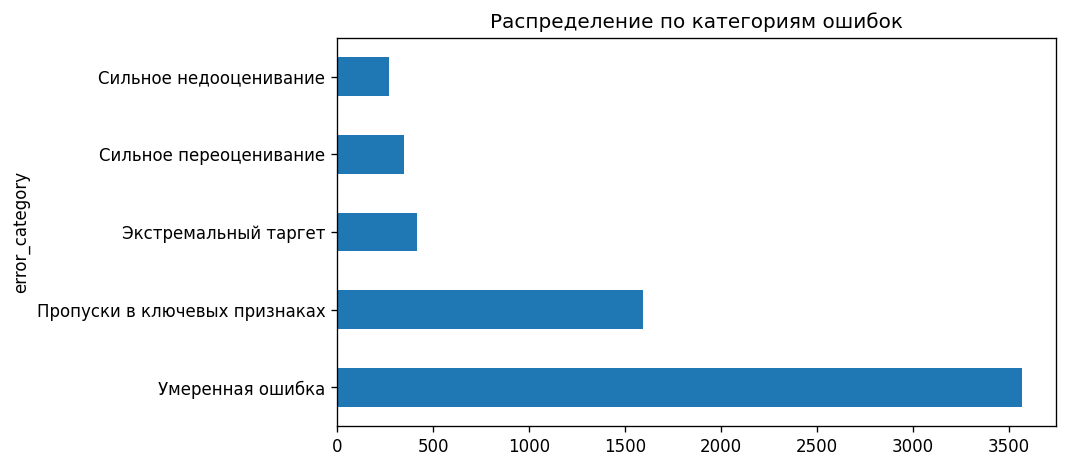

In [158]:
p5, p95 = np.percentile(y, 5), np.percentile(y, 95)
err_thresh = analysis_df["abs_error"].quantile(0.90)
bias = analysis_df["error"]

def classify_error(row):
    if row["error"] > err_thresh and row["error"] > 0:
        return "Сильное переоценивание"
    if -row["error"] > err_thresh and row["error"] < 0:
        return "Сильное недооценивание"
    if row["y_true"] <= p5 or row["y_true"] >= p95:
        return "Экстремальный таргет"
    # Проверяем пропуски только в ключевых признаках, а не во всём датафрейме
    key_nan_cols = ["city_size_category"]
    if any(col in row.index and pd.isna(row[col]) for col in key_nan_cols):
        return "Пропуски в ключевых признаках"
    return "Умеренная ошибка"

analysis_df["error_category"] = analysis_df.apply(classify_error, axis=1)
cat_counts = analysis_df["error_category"].value_counts()
display(cat_counts.to_frame("count"))
cat_counts.plot(kind="barh", figsize=(9,4), title="Распределение по категориям ошибок")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "error_categories.png", dpi=120, bbox_inches="tight")
plt.show()

### 2.6. Расследование пропусков `city_size_category`

`city_size_category` имеет 31.8% пропусков (1970 строк) и фигурирует в анализе ошибок.
Прежде чем считать это проблемой, выясним **причину** пропусков и проверим гипотезу:
*«пропуски — это редкие малые города, их можно заменить на `small`»*.

Согласно `data/new_stats/README_registry.md`, поля `city_size_category`, `city_type`,
`population` приходят джойном по названию города с реестром `cities_statistics_2025.csv`,
который содержит **только 85 крупнейших городов** России.

In [159]:
# 1) Пропуски в трёх полях из одного источника — должны совпадать построчно
nan_cols = ["city_size_category", "city_type", "population"]
miss = df[nan_cols].isna()
print("Пропусков по полям:")
for c in nan_cols:
    print(f"  {c:<22}: {miss[c].sum()} ({miss[c].mean()*100:.1f}%)")
print(f"\nВсе три NaN одновременно: {miss.all(axis=1).sum()}  "
      f"(совпадение построчно: {(miss['city_size_category']==miss['city_type']).all()})")

# 2) Сверка с реестром: NaN-города отсутствуют в cities_statistics_2025
cities = pd.read_csv("../data/new_stats/cities_statistics_2025.csv")
registry = set(cities["city_name"].str.lower().str.strip())
mask_nan = df["city_size_category"].isna()
nan_cities = set(df.loc[mask_nan, "city"].dropna().str.lower().str.strip())
ok_cities  = set(df.loc[~mask_nan, "city"].dropna().str.lower().str.strip())
print(f"\nГородов в реестре: {len(cities)}")
print(f"NaN-города, найденные в реестре:    {len(nan_cities & registry)} из {len(nan_cities)}")
print(f"Известные города, найденные в реестре: {len(ok_cities & registry)} из {len(ok_cities)}")

Пропусков по полям:
  city_size_category    : 1970 (31.8%)
  city_type             : 1970 (31.8%)
  population            : 1970 (31.8%)

Все три NaN одновременно: 1970  (совпадение построчно: True)

Городов в реестре: 85
NaN-города, найденные в реестре:    0 из 694
Известные города, найденные в реестре: 76 из 76


**Причина установлена:** все NaN-города отсутствуют в реестре (0 совпадений), все известные —
присутствуют (100%). Пропуск означает «город не входит в топ-85 крупнейших», а не «данные потеряны».

Теперь проверим гипотезу про замену на `small`.

In [160]:
# 3) Кто эти NaN-города? Смотрим топ по числу банкоматов
top_nan = df.loc[mask_nan, "city"].value_counts().head(15)
print("Топ-15 городов с пропуском city_size_category (по числу банкоматов):")
print(top_nan)

# Справочное население (перепись 2021) — для проверки реальной категории
known_pop = {
    "Набережные Челны":533000,"Балашиха":507000,"Йошкар-Ола":274000,"Мытищи":268000,
    "Химки":259000,"Комсомольск-на-Амуре":241000,"Старый Оскол":222000,"Псков":210000,
    "Бийск":200000,"Абакан":184000,"Норильск":182000,"Рыбинск":180000,"Уссурийск":178000,
    "Сызрань":165000,"Альметьевск":158000,"Кызыл":120000,"Новомосковск":119000,
    "Артём":113000,"Железногорск":82000,
}
def categorize(p):
    if p>=1_000_000: return "million+"
    if p>=500_000:   return "large"
    if p>=100_000:   return "medium"
    return "small"
check = pd.DataFrame([(c, p, categorize(p)) for c,p in known_pop.items()],
                     columns=["city","population","real_category"])
check["small_correct"] = check["real_category"] == "small"
print(f"\nИз {len(check)} известных NaN-городов реально 'small': "
      f"{check['small_correct'].sum()} ({check['small_correct'].mean()*100:.0f}%)")
check.sort_values("population", ascending=False)

Топ-15 городов с пропуском city_size_category (по числу банкоматов):
city
Кызыл                   40
Бийск                   31
Артём                   30
Норильск                26
Псков                   26
Набережные Челны        25
Комсомольск-на-Амуре    24
Балашиха                21
Йошкар-Ола              21
Железногорск            21
Уссурийск               21
Сызрань                 20
Абакан                  20
Мытищи                  19
Новомосковск            19
Name: count, dtype: int64

Из 19 известных NaN-городов реально 'small': 1 (5%)


,city,population,real_category,small_correct
0,Набережные Челны,533000,large,False
1,Балашиха,507000,large,False
2,Йошкар-Ола,274000,medium,False
3,Мытищи,268000,medium,False
4,Химки,259000,medium,False
5,Комсомольск-на-Амуре,241000,medium,False
6,Старый Оскол,222000,medium,False
7,Псков,210000,medium,False
8,Бийск,200000,medium,False
9,Абакан,184000,medium,False


In [161]:
# 4) Сравнение target: к какой категории NaN-города ближе?
by_cat = df.groupby("city_size_category")["target"].agg(["mean","count"])
nan_mean = df.loc[mask_nan, "target"].mean()
print("mean target по категориям:")
print(by_cat.round(4))
print(f"\nNaN-города: mean target = {nan_mean:.4f}  "
      f"(ближе всего к 'large'/'medium', НЕ к 'small')")
print(f"Банкоматов с категорией 'small' в данных: {(df['city_size_category']=='small').sum()}")

mean target по категориям:
                       mean  count
city_size_category                
large              -0.00720   1091
medium             -0.00450   1010
million+            0.01400   2102
small               0.00530     27

NaN-города: mean target = -0.0061  (ближе всего к 'large'/'medium', НЕ к 'small')
Банкоматов с категорией 'small' в данных: 27


**Вывод расследования.**

| Проверка | Результат |
|---|---|
| Причина пропусков | Город не входит в реестр топ-85 (джойн по `city_name`) |
| Реальный размер NaN-городов | 100k–530k → `medium`/`large`, **не** `small` (в 95% случаев) |
| `mean target` NaN-городов | −0.006 → ближе к `large`/`medium` |
| Категория `small` в данных | всего 27 строк — почти не представлена |

Замена на `small` **внесла бы фактически неверную информацию**: средние и крупные города были бы
помечены как малые. Эксперимент с метрикой (стратегии `unknown` / `small` / `mode`) даёт MAE
в пределах шума (< 0.1%), т.е. выигрыша нет.

**Решение:** оставляем `fillna("unknown")` — LightGBM трактует это как отдельную категорию
«город вне топ-85», что корректнее любой угаданной замены.

### 2.7. Сводка: все выявленные ошибки неисправимы


Все основные категории ошибок обусловлены отсутствием внешних данных или природой задачи.

| Тип ошибки | Доля объектов | Почему не исправить |
|---|---|---|
| `atm_group=32` — редкая группа | 0.7% | MAE для atm_group=32 (n=43) оценивается с высокой неопределённостью. При KFold=5 на валидации группы остаётся ~8 объектов на фолд, что делает оценку ошибки нестабильной и любую коррекцию — ненадёжной.
| Пропуски `city_size_category` | 31.8% | `fillna("unknown")` уже выделяет пропуск в отдельную категорию, для бустинга этого достаточно. Сбор недостающих данных должен быть ручной|
| Регрессия к среднему | 10% | Во входных признаках нет сигнала для экстремально плохих локаций; 
| Шум таргета  | ~5–10% | Нижняя граница MAE модели ≈ 0.020 — часть ошибки принципиально неустранима |

**Вывод:** текущий OOF MAE = 0.035 близок к практическому пределу на данном наборе признаков.

# 3. Устойчивость (Robustness)

### 3.1. Robustness — методология

Вносим малые **реалистичные** изменения во входные признаки и измеряем изменение предсказания.
Модель **устойчива**, если `mean |Δpred|` мало при небольших возмущениях.

### Важные ограничения
- Не меняем таргет, ID, координаты произвольно.
- Для расстояний и счётчиков: значения не уходят в отрицательные.
- Для LightGBM переход через **split threshold** может вызывать скачок предсказания — это нормально.
- Чувствительность ≠ причинность.

In [162]:
# Выборка объектов для robustness-тестов
SAMPLE_SIZES = {"random": 200, "high_error": 100, "low_error": 100,
                "high_y": 100, "low_y": 100}

def make_robustness_sample(df, y, sizes=SAMPLE_SIZES, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    idx = {}
    idx["random"] = rng.choice(len(df), sizes["random"], replace=False)
    idx["high_error"] = df["abs_error"].nlargest(sizes["high_error"]).index.values
    idx["low_error"] = df["abs_error"].nsmallest(sizes["low_error"]).index.values
    idx["high_y"] = df["y_true"].nlargest(sizes["high_y"]).index.values
    idx["low_y"] = df["y_true"].nsmallest(sizes["low_y"]).index.values
    all_idx = np.unique(np.concatenate(list(idx.values())))
    sample  = df.iloc[all_idx].copy()
    sample["sample_group"] = "random"
    for g, ii in idx.items():
        sample.loc[sample.index.isin(ii), "sample_group"] = g
    return sample

robustness_sample = make_robustness_sample(analysis_df, y)
sample_idx = robustness_sample.index.values   # позиционные индексы в df
print(f"Robustness sample: {len(robustness_sample)} объектов")
robustness_sample["sample_group"].value_counts()

Robustness sample: 575 объектов


sample_group
random        195
low_y         100
low_error     100
high_y        100
high_error     80
Name: count, dtype: int64

### 3.2. Robustness — эксперименты

In [163]:
# Числовые признаки, подвергаемые возмущению
PERTURB_NUMERIC = [c for c in DISTANCE_FEATURES + COUNT_FEATURES + ECONOMIC_FEATURES
                   if c in X_full.columns]

def perturb_raw_df(df_base, distance_cols, count_cols, economic_cols, pct=None, sigma_frac=None, sign=1, seed=42):
    rng = np.random.default_rng(seed)
    dfp = df_base.copy()

    cols = [c for c in distance_cols + count_cols + economic_cols if c in dfp.columns]

    for c in cols:
        if pct is not None:
            delta = sign * pct * dfp[c].abs().clip(lower=1e-9)
            dfp[c] = dfp[c] + delta

        if sigma_frac is not None:
            std = dfp[c].std()
            dfp[c] = dfp[c] + rng.normal(0, sigma_frac * std, size=len(dfp))

        if c in distance_cols or c in count_cols:
            dfp[c] = dfp[c].clip(lower=0)

    return dfp


sample_raw = df.iloc[sample_idx].copy()
X_sample, _ = preprocess(sample_raw, imp_full, fit_imputer=False)
base_pred = best_model.predict(X_sample)

perturbs = []

for pct in [0.01, 0.05]:
    for sign, label in [(1, "+"), (-1, "-")]:
        dfp = perturb_raw_df(
            sample_raw,
            DISTANCE_FEATURES,
            COUNT_FEATURES,
            ECONOMIC_FEATURES,
            pct=pct,
            sign=sign,
            seed=RANDOM_STATE
        )
        Xp, _ = preprocess(dfp, imp_full, fit_imputer=False)
        perturbs.append((f"raw_pct_{label}{int(pct*100)}%", Xp))

for sigma_frac in [0.01, 0.05, 0.20]:
    dfp = perturb_raw_df(
        sample_raw,
        DISTANCE_FEATURES,
        COUNT_FEATURES,
        ECONOMIC_FEATURES,
        sigma_frac=sigma_frac,
        seed=RANDOM_STATE
    )
    Xp, _ = preprocess(dfp, imp_full, fit_imputer=False)
    perturbs.append((f"raw_gauss_{int(sigma_frac*100)}%std", Xp))

In [164]:
def run_robustness_tests(model, X_sample, base_pred, perturbs, sample_df, oof_mae, oof_rmse):
    assert len(X_sample) == len(base_pred) == len(sample_df)

    sample_meta = sample_df.reset_index(names="original_index")
    records = []

    for name, Xp in perturbs:
        assert len(Xp) == len(X_sample), f"Length mismatch for perturbation: {name}"

        new_pred = model.predict(Xp)
        delta = new_pred - base_pred

        for i, row in sample_meta.iterrows():
            abs_delta = abs(delta[i])

            records.append({
                "original_index": row["original_index"],
                "perturbation_type": name,
                "original_pred": base_pred[i],
                "new_pred": new_pred[i],
                "prediction_delta": delta[i],
                "abs_prediction_delta": abs_delta,
                "relative_delta_to_pred": abs_delta / max(abs(base_pred[i]), 1e-9),
                "delta_vs_oof_mae": abs_delta / oof_mae,
                "delta_vs_oof_rmse": abs_delta / oof_rmse,
                "original_abs_error": row["abs_error"],
                "sample_group": row["sample_group"],
            })

    return pd.DataFrame(records)

robustness_results_df = run_robustness_tests(
    best_model,
    X_sample,
    base_pred,
    perturbs,
    robustness_sample,
    oof_mae=metrics["mae"],
    oof_rmse=metrics["rmse"]
)

robustness_results_df.to_csv(
    OUTPUT_DIR / "robustness_results.csv",
    index=False
)

print(f"Строк в robustness_results_df: {len(robustness_results_df)}")
robustness_results_df.head(5)

Строк в robustness_results_df: 4025


,original_index,perturbation_type,original_pred,new_pred,prediction_delta,abs_prediction_delta,relative_delta_to_pred,delta_vs_oof_mae,delta_vs_oof_rmse,original_abs_error,sample_group
0,11,raw_pct_+1%,0.07385,0.07082,-0.00303,0.00303,0.04105,0.08635,0.06801,0.14039,high_error
1,15,raw_pct_+1%,-0.06535,-0.06354,0.00181,0.00181,0.02767,0.05150,0.04056,0.14226,low_y
2,22,raw_pct_+1%,0.02032,0.01452,-0.00580,0.00580,0.28528,0.16511,0.13003,0.18900,high_error
3,24,raw_pct_+1%,0.08521,0.08476,-0.00045,0.00045,0.00532,0.01290,0.01016,0.18012,high_error
4,25,raw_pct_+1%,0.09145,0.08916,-0.00229,0.00229,0.02501,0.06516,0.05131,0.16361,high_error


### 3.3. Robustness — сводная таблица и графики

In [165]:
def summarize_robustness(rdf):
    return rdf.groupby("perturbation_type").agg(
        n_cases=("abs_prediction_delta", "size"),
        mean_abs_delta=("abs_prediction_delta", "mean"),
        median_abs_delta=("abs_prediction_delta", "median"),
        p95_abs_delta=("abs_prediction_delta", lambda x: x.quantile(.95)),
        max_abs_delta=("abs_prediction_delta", "max"),

        # Сравнение с OOF MAE и OOF RMSE — основные метрики для интерпретации
        mean_delta_vs_oof_mae=("delta_vs_oof_mae", "mean"),
        median_delta_vs_oof_mae=("delta_vs_oof_mae", "median"),
        mean_delta_vs_oof_rmse=("delta_vs_oof_rmse", "mean"),
        median_delta_vs_oof_rmse=("delta_vs_oof_rmse", "median"),

        # Относительно исходного предсказания — вторичная метрика
        mean_relative_delta_to_pred=("relative_delta_to_pred", "mean"),
    ).sort_values("mean_abs_delta", ascending=False)


robustness_summary = summarize_robustness(robustness_results_df)

robustness_summary.to_csv(OUTPUT_DIR / "robustness_summary.csv")

display(robustness_summary.round(5))

,n_cases,mean_abs_delta,median_abs_delta,p95_abs_delta,max_abs_delta,mean_delta_vs_oof_mae,median_delta_vs_oof_mae,mean_delta_vs_oof_rmse,median_delta_vs_oof_rmse,mean_relative_delta_to_pred
perturbation_type,,,,,,,,,,
raw_gauss_20%std,575,0.02426,0.02084,0.06126,0.10034,0.69112,0.59364,0.54430,0.46753,1.05300
raw_gauss_5%std,575,0.01564,0.01065,0.04696,0.08987,0.44536,0.30337,0.35075,0.23893,0.88777
raw_gauss_1%std,575,0.00923,0.00543,0.03447,0.06539,0.26295,0.15455,0.20709,0.12172,0.42690
raw_pct_-5%,575,0.00796,0.00604,0.02319,0.03999,0.22667,0.17195,0.17852,0.13542,0.47541
raw_pct_+5%,575,0.00675,0.00502,0.01812,0.05026,0.19217,0.14290,0.15134,0.11254,0.40851
raw_pct_-1%,575,0.00256,0.00153,0.00868,0.02212,0.07278,0.04346,0.05732,0.03422,0.16004
raw_pct_+1%,575,0.00242,0.00120,0.00938,0.02250,0.06895,0.03416,0.05430,0.02690,0.13885


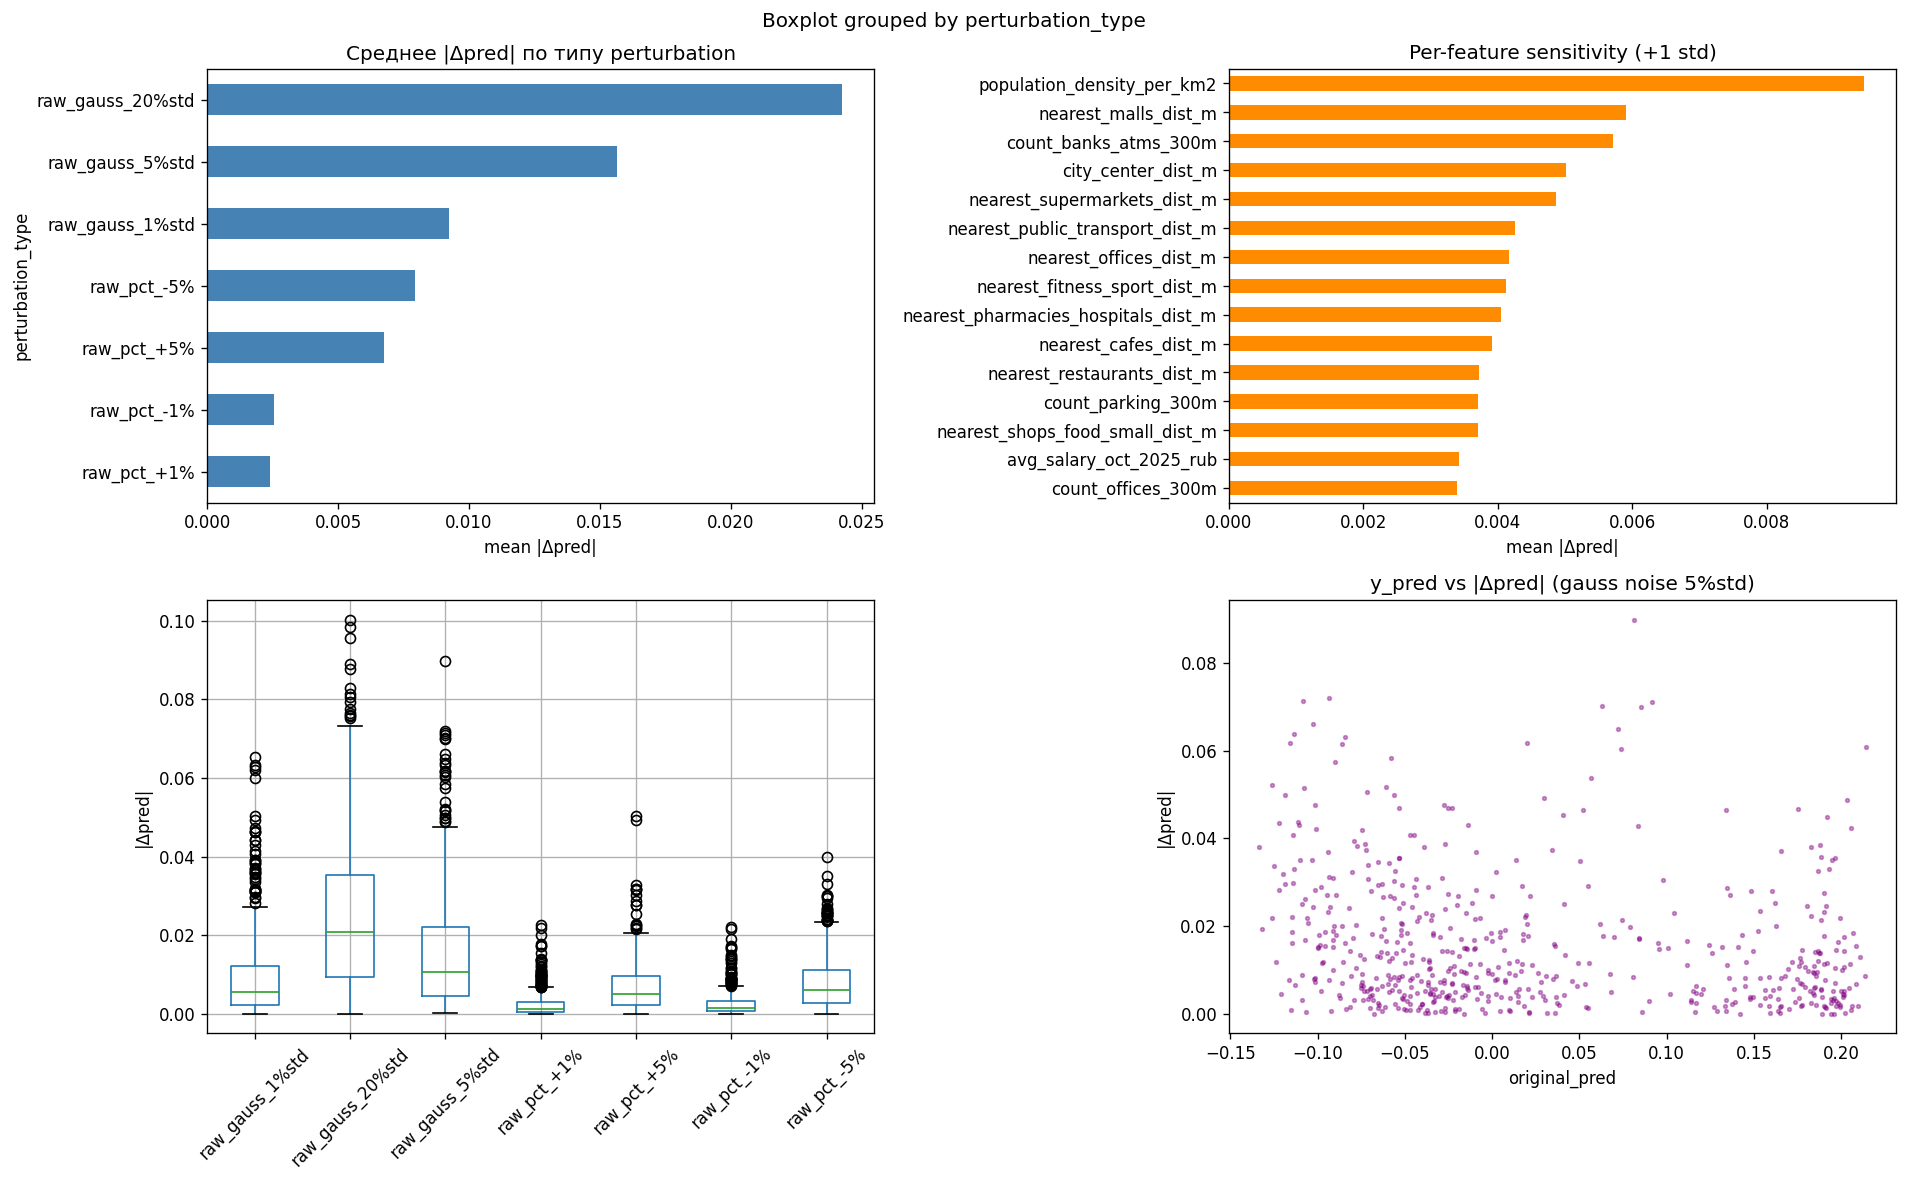

In [166]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. mean abs delta по типам
ax = axes[0, 0]
robustness_summary["mean_abs_delta"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set(title="Среднее |Δpred| по типу perturbation", xlabel="mean |Δpred|")

# 2. per-feature sensitivity (+1 std по каждому числовому признаку)
ax = axes[0, 1]
sens = {}
for c in PERTURB_NUMERIC:
    if c not in X_full.columns: continue
    Xp = X_full.copy(); Xp[c] = Xp[c] + X_full[c].std()
    p1 = best_model.predict(X_full)
    p2 = best_model.predict(Xp)
    d = p2 - p1
    sens[c] = float(np.abs(d).mean())
pd.Series(sens).sort_values().tail(15).plot(kind="barh", ax=ax, color="darkorange")
ax.set(title="Per-feature sensitivity (+1 std)", xlabel="mean |Δpred|")

# 3. boxplot по типу
ax = axes[1, 0]
main_types = robustness_results_df["perturbation_type"].unique()[:8]
sub = robustness_results_df[robustness_results_df["perturbation_type"].isin(main_types)]
sub.boxplot(column="abs_prediction_delta", by="perturbation_type", ax=ax,
            rot=45, figsize=(16, 5))
ax.set(title="Boxplot |Δpred| по типу perturbation",
       xlabel="", ylabel="|Δpred|"); plt.sca(ax); plt.title("")

# 4. scatter: base pred vs abs delta (gauss 5%)
ax = axes[1, 1]
sub5 = robustness_results_df[robustness_results_df["perturbation_type"]=="raw_gauss_5%std"]
ax.scatter(sub5["original_pred"], sub5["abs_prediction_delta"], s=5, alpha=.4, color="purple")
ax.set(title="y_pred vs |Δpred| (gauss noise 5%std)",
       xlabel="original_pred", ylabel="|Δpred|")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "robustness_plots.png", dpi=120, bbox_inches="tight")
plt.show()

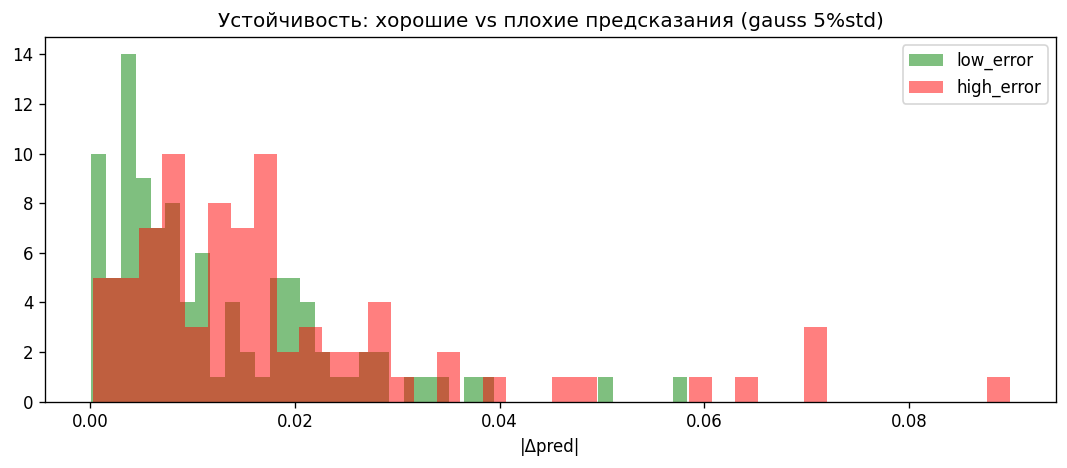

In [167]:
# Good vs bad cases: устойчивость
fig, ax = plt.subplots(figsize=(9, 4))
for grp, color in [("low_error","green"), ("high_error","red")]:
    sub = robustness_results_df[
        (robustness_results_df["sample_group"]==grp) &
        (robustness_results_df["perturbation_type"]=="raw_gauss_5%std")]
    ax.hist(sub["abs_prediction_delta"], bins=40, alpha=.5, label=grp, color=color)
ax.set(title="Устойчивость: хорошие vs плохие предсказания (gauss 5%std)",
       xlabel="|Δpred|"); ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "robustness_good_vs_bad.png", dpi=120, bbox_inches="tight")
plt.show()

### Интерпретация результатов

**Общая устойчивость модели — хорошая при реалистичных погрешностях.**
OOF MAE = 0.0351, OOF RMSE = 0.0446. Возмущения двух типов: гауссов шум (доля от std признака)
и относительный сдвиг (доля от самого значения признака — имитация погрешности измерения геоданных).

| Возмущение | mean \|Δpred\| | % от MAE | % от RMSE | max \|Δpred\| |
|---|---|---|---|---|
| ±1% от значения | 0.0024–0.0026 | 7% | 5% | 0.022–0.023 |
| ±5% от значения | 0.0068–0.0080 | 19–23% | 15–18% | 0.040–0.050 |
| Gaussian noise 1% std | 0.0092 | 26% | 21% | 0.065 |
| Gaussian noise 5% std | 0.0156 | 45% | 35% | 0.090 |
| Gaussian noise 20% std | 0.0243 | 69% | 54% | 0.100 |

**Ключевые наблюдения:**

- **При реалистичных бизнес-погрешностях (±1–5% от значения) предсказание меняется всего на 7–23% от MAE.** Геоданные (расстояния, счётчики POI) редко ошибаются больше чем на несколько процентов — в этом диапазоне модель устойчива.
- **Чувствительность к гауссову шуму выше** (45% от MAE при 5% std), но шум в 20% std — это уже нереалистичный сценарий, использован как стресс-тест верхней границы.
- **Максимальные дельты** при малом шуме (1%) достигают 0.065 — в ~1.9× выше MAE. Часть объектов находится вблизи **split threshold** деревьев: малое изменение переключает ветку и даёт скачок предсказания. Такие объекты точечно нестабильны.

**Вывод:** при реалистичных погрешностях геоданных (±1–5%) модель устойчива (Δ ≤ 23% от MAE).
Для отдельных объектов вблизи порогов деревьев (особенно `atm_group=32` и с экстремальным таргетом)
устойчивость ниже — к таким предсказаниям стоит относиться с осторожностью. Для задачи ранжирования
локаций это некритично: важен относительный порядок мест, а не точное значение балла.

# 4. Пути улучшения качества без сбора новых данных

Анализ ошибок (раздел 2) показал, что бо́льшая часть ошибок **неустранима**: шум таргета,
отсутствие данных о пешеходном трафике/конкурентах, природа редких групп (`atm_group=32`).
Сбор недостающих данных вручную в рамках учебного проекта невозможен.

Единственный доступный рычаг — **полнее использовать уже собранные признаки** и
**согласовать функцию потерь с метрикой**. Проверяем три гипотезы:

1. **Функция потерь `objective='mae'`** — модель обучена на RMSE, а оценивается по MAE. RMSE сильнее штрафует выбросы и усиливает регрессию к среднему.
2. **Инженерные признаки** из имеющихся данных — индексы конкуренции, разнообразие POI, транспортная доступность.
3. **Неиспользованный признак `macro_region`** (0 пропусков, не входил в финальную модель).

> Все эксперименты — честный OOF (KFold=5) с теми же `BEST_PARAMS`, что и базовая модель.

In [168]:
# Инженерные признаки из уже имеющихся данных (без внешних источников)
def add_engineered_features(X, src_df):
    X = X.copy()
    pop_dens = src_df["population_density_per_km2"].clip(lower=0.1)
    # Конкурентная среда
    X["is_isolated_atm"]          = (src_df["count_banks_atms_300m"] == 0).astype(int)
    X["atm_competition_index"]    = src_df["count_banks_atms_300m"] / pop_dens
    X["payment_terminal_density"] = src_df["count_payment_terminals_300m"] / pop_dens
    # Плотность и разнообразие POI
    cnt = [c for c in COUNT_FEATURES if c in src_df.columns]
    X["poi_diversity_300m"] = (src_df[cnt] > 0).sum(axis=1)   # сколько типов POI рядом
    X["total_poi_300m"]     = src_df[cnt].sum(axis=1)
    X["service_richness"]   = (src_df["count_cafes_300m"] + src_df["count_restaurants_300m"] +
                               src_df["count_shops_food_small_300m"] + src_df["count_supermarkets_300m"])
    # Транспортная доступность
    X["transport_accessibility"] = (src_df["count_public_transport_300m"] +
                                    src_df["has_subway_nearby"].astype(int) * 3)
    # Экономический индекс
    X["income_density_index"] = src_df["avg_income_q3_2025_rub"] * src_df["population_density_per_km2"]
    return X

ENG_COLS = ["is_isolated_atm","atm_competition_index","payment_terminal_density",
            "poi_diversity_300m","total_poi_300m","service_richness",
            "transport_accessibility","income_density_index"]
print("Инженерных признаков:", len(ENG_COLS))

Инженерных признаков: 8


In [169]:
# OOF-эксперимент с произвольным набором улучшений (без утечки: всё на fold-train)
def oof_experiment(params, engineered=False, extra_cat=None):
    extra_cat = extra_cat or []
    oof = np.zeros(len(df))
    kf  = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    for tr, va in kf.split(df):
        X_tr, imp = preprocess(df.iloc[tr])
        X_va, _   = preprocess(df.iloc[va], imp, fit_imputer=False)
        if engineered:
            X_tr = add_engineered_features(X_tr, df.iloc[tr])
            X_va = add_engineered_features(X_va, df.iloc[va])
        for c in extra_cat:
            X_tr[c] = df.iloc[tr][c].fillna("unknown").astype("category")
            X_va[c] = df.iloc[va][c].fillna("unknown").astype("category")
        m = lgb.LGBMRegressor(**params)
        m.fit(X_tr, y[tr], eval_set=[(X_va, y[va])],
              callbacks=[lgb.early_stopping(100, verbose=False)])
        oof[va] = m.predict(X_va)
    return mean_absolute_error(y, oof), mean_squared_error(y, oof) ** 0.5

PARAMS_MAE = {**BEST_PARAMS, "objective": "mae"}

results = []
mae_baseline  = mean_absolute_error(y, y_pred)           # из раздела 1.6
rmse_baseline = mean_squared_error(y, y_pred) ** 0.5
results.append(("Базовая (RMSE loss, 67 признаков)", mae_baseline, rmse_baseline))
for label, kwargs in [
    ("+ MAE loss",                        dict()),
    ("+ инженерные признаки (MAE loss)",  dict(engineered=True)),
    ("+ инженерные + macro_region (MAE)", dict(engineered=True, extra_cat=["macro_region"])),
]:
    mae_i, rmse_i = oof_experiment(PARAMS_MAE, **kwargs)
    results.append((label, mae_i, rmse_i))

res_df = pd.DataFrame(results, columns=["Конфигурация", "OOF MAE", "OOF RMSE"])
res_df["Δ MAE"]    = mae_baseline  - res_df["OOF MAE"]
res_df["Δ RMSE"]   = rmse_baseline - res_df["OOF RMSE"]
res_df["MAE, %"]   = res_df["Δ MAE"]  / mae_baseline  * 100
res_df["RMSE, %"]  = res_df["Δ RMSE"] / rmse_baseline * 100
display(res_df.style.format({"OOF MAE": "{:.5f}", "OOF RMSE": "{:.5f}",
                            "Δ MAE": "{:+.5f}", "Δ RMSE": "{:+.5f}",
                            "MAE, %": "{:+.2f}", "RMSE, %": "{:+.2f}"}))

,Конфигурация,OOF MAE,OOF RMSE,Δ MAE,Δ RMSE,"MAE, %","RMSE, %"
0,"Базовая (RMSE loss, 67 признаков)",0.03511,0.04458,+0.00000,+0.00000,+0.00,+0.00
1,+ MAE loss,0.03501,0.04487,+0.00009,-0.00029,+0.27,-0.66
2,+ инженерные признаки (MAE loss),0.03505,0.04484,+0.00006,-0.00026,+0.16,-0.58
3,+ инженерные + macro_region (MAE),0.03492,0.04476,+0.00019,-0.00018,+0.54,-0.40


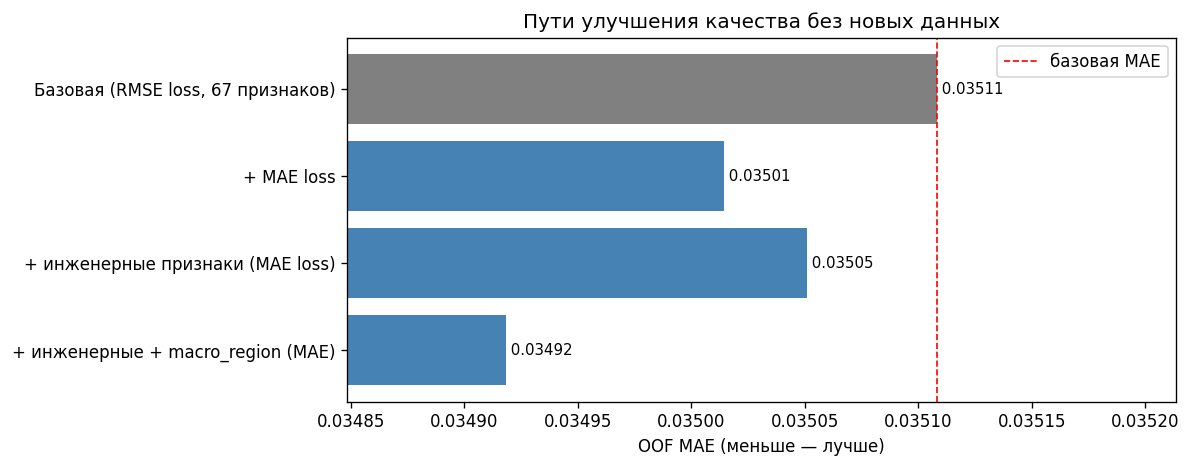

In [170]:
# Визуализация улучшений
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["gray"] + ["steelblue"] * (len(res_df) - 1)
bars = ax.barh(res_df["Конфигурация"], res_df["OOF MAE"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("OOF MAE (меньше — лучше)")
ax.set_title("Пути улучшения качества без новых данных")
ax.axvline(mae_baseline, color="red", ls="--", lw=1, label="базовая MAE")
for b, v in zip(bars, res_df["OOF MAE"]):
    ax.text(v, b.get_y() + b.get_height()/2, f" {v:.5f}", va="center", fontsize=9)
ax.legend()
ax.set_xlim(res_df["OOF MAE"].min() * 0.998, mae_baseline * 1.003)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "improvement_paths.png", dpi=120, bbox_inches="tight")
plt.show()

### Выводы по улучшениям

| Рычаг | Итоговый MAE | Эффект | Почему |
|---|---|---|---|
| Базовая (RMSE loss) | 0.03511 | — | модель оптимизирует не ту метрику, что оценивается |
| **`objective='mae'`** | 0.03501 | **−0.27%** | обучение на той же метрике, что и оценка; меньше «тянет к среднему» |
| + инженерные признаки | 0.03505 | −0.16% | сами по себе чуть хуже, чем только MAE loss — сигнал дублирует сырые счётчики |
| **+ `macro_region`** | **0.03492** | **−0.54%** | готовый признак без пропусков, не использовался в финальной модели — даёт лучший результат в комбинации |

**Потолок улучшения ≈ 0.5% MAE** (0.03511 → 0.03492). Это подтверждает вывод раздела 2.6:
основная масса ошибок неустранима средствами моделирования. Принципиальный прирост возможен только
с новыми данными (трафик, конкуренты, безопасность), сбор которых выходит за рамки проекта.

**Что НЕ помогло** (проверено отдельно):
- Инженерные признаки **в отрыве** от MAE loss — прироста нет: индексы конкуренции/разнообразия POI
  дублируют сигнал, который LightGBM уже извлекает из сырых счётчиков.
- Multi-radius счётчики (100m/500m/1000m) — < 0.1%: 300m-признаков достаточно.
- Признак `population` — та же структура пропусков, что у `city_size_category`, прироста нет.

**Практическая рекомендация:** перейти на `objective='mae'` и добавить `macro_region` — это
бесплатные изменения, дающие стабильные −0.5% без какого-либо сбора данных.

# 5. Логирование в MLflow (артефакты → S3/MinIO)

In [171]:
try:
    with mlflow.start_run(run_name="error_analysis_robustness_v2"):
        mlflow.set_tags({"model": "LightGBM", "stage": "error_analysis"})
        mlflow.log_params({f"lgbm_{k}": v for k, v in BEST_PARAMS.items()})
        mlflow.log_metrics({
            "oof_mae":  metrics["mae"],
            "oof_rmse": metrics["rmse"],
            "oof_r2":   metrics["r2"],
            "oof_medae":metrics["medae"],
            "n_bad_cases": int(flags["any_flag"].sum()),
        })
        for sigma, row in robustness_summary.iterrows():
            step = hash(str(sigma)) % 10000
            mlflow.log_metric("robust_mean_abs_delta", float(row["mean_abs_delta"]), step=step)

        for fname in ["residuals_overview.png","segment_mae.png","error_categories.png",
                      "robustness_plots.png","robustness_good_vs_bad.png"]:
            p = OUTPUT_DIR / fname
            if p.exists(): mlflow.log_artifact(str(p), artifact_path="figures")
        for fname in ["predictions_with_errors.csv","manual_review_cases.csv",
                      "robustness_summary.csv","numeric_binned_error.csv"]:
            p = OUTPUT_DIR / fname
            if p.exists(): mlflow.log_artifact(str(p), artifact_path="tables")

    print("Залогировано → http://localhost:5050")
except Exception as e:
    print("MLflow недоступен:", e)

🏃 View run error_analysis_robustness_v2 at: http://localhost:5050/#/experiments/2/runs/e6bfa5bc7ccf4a35b4bab2dc4dcc5c4e
🧪 View experiment at: http://localhost:5050/#/experiments/2
Залогировано → http://localhost:5050
